<a href="https://colab.research.google.com/github/Dyuko/DataScience/blob/main/analisis_sentimientos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Alumno: Matías Irala

CI: 4637852

In [1]:
!pip install datasets
!pip install evaluate
!pip install transformers==4.28.0

In [2]:
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [3]:
from datasets import load_dataset, Dataset, Features, ClassLabel, Sequence, Value, DatasetDict
import pandas as pd

In [4]:
import re

In [5]:
from transformers import AutoTokenizer

In [6]:
from transformers import AutoModelForSequenceClassification

In [7]:
from transformers import TrainingArguments

In [8]:
from transformers import Trainer

In [9]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import numpy as np

In [10]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Parte 1: Preprocesamiento del conjunto de datos

## Lectura del dataset: Descarga y lee el conjunto de datos del TASS 2020.

In [11]:
# Lectura del archivo donde se encuentran los datos de entrenamiento y validación
data = pd.read_csv('/content/gdrive/MyDrive/datos/corpusTASS-2020/train.tsv', sep='\t')
data_dev = pd.read_csv('/content/gdrive/MyDrive/datos/corpusTASS-2020/dev.tsv', sep='\t')

## Estructura de datos: Extrae los tweets y sus etiquetas de sentimiento, y almacénalos en un objeto datasets.Dataset usando la librería datasets de Hugging Face.

In [12]:
data = data.drop(columns=['id', 'pais'])
data_dev = data_dev.drop(columns=['id', 'pais'])

In [13]:
# Diccionario de mapeo de etiquetas
mapeo_etiquetas = {'N': 0, 'NEU': 1, 'P': 2}

#definimos la estructura del dataset de Huggingface
features = Features({
    'texto': Value('string'),
    'etiqueta': ClassLabel(num_classes=3, names=['N', 'NEU', 'P'])
})

#transformamos de dataframe a dataset
dataset_train = Dataset.from_pandas(data, features=features)
dataset_dev = Dataset.from_pandas(data_dev, features=features)

dataset_train = dataset_train.rename_column("texto", "text")
dataset_train = dataset_train.rename_column("etiqueta", "label")
dataset_dev = dataset_dev.rename_column("texto", "text")
dataset_dev = dataset_dev.rename_column("etiqueta", "label")

#creamos diccionario de dataset
dataset = DatasetDict({'train': dataset_train, 'test': dataset_dev})
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 4802
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2443
    })
})

## Limpieza del texto (opcional): Elimina o normaliza elementos como URLs, menciones (@usuario), hashtags, emojis, etc.

In [14]:
dataset['train'][0]

{'text': '@morbosaborealis jajajaja... eso es verdad... aquí no hay uno cuerdo ',
 'label': 0}

In [15]:
def preprocess_text(text):
    # Eliminar URLs completamente
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    # Eliminar menciones (@usuario) completamente
    text = re.sub(r'@\w+', '', text)
    # Eliminar hashtags (#palabra) completamente
    text = re.sub(r'#\w+', '', text)
    # Eliminar emojis y otros caracteres no ASCII
    # Esta expresión regular elimina todos los caracteres que no sean ASCII estándar
    # lo que incluye emojis y otros caracteres especiales
    text = re.sub(r'[^\x00-\x7F]+', '', text)
    # Eliminar espacios múltiples que pueden quedar después de las eliminaciones
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

In [16]:
dataset['train'] = dataset['train'].map(lambda x: {'text': preprocess_text(x['text'])})
dataset['test'] = dataset['test'].map(lambda x: {'text': preprocess_text(x['text'])})

Map:   0%|          | 0/4802 [00:00<?, ? examples/s]

Map:   0%|          | 0/2443 [00:00<?, ? examples/s]

In [17]:
dataset['train'][0]

{'text': 'jajajaja... eso es verdad... aqu no hay uno cuerdo', 'label': 0}

# Parte 2: Ajuste fino del modelo preentrenado

## Selección del modelo base:
Utiliza un modelo en español preentrenado desde Hugging Face (sin ajuste previo de sentimientos), por ejemplo:

dccuchile/bert-base-spanish-wwm-cased

bertin-project/bertin-roberta-base-spanish

pysentimiento/robertuito-base-(cased o uncased)

In [18]:
#model_checkpoint = "pysentimiento/robertuito-base-cased"
model_checkpoint = "bertin-project/bertin-roberta-base-spanish"
#model_checkpoint = "dccuchile/bert-base-spanish-wwm-cased"
#model_checkpoint = "PlanTL-GOB-ES/roberta-base-bne"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/file_download.py:896: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


## Tokenización:
Usa el tokenizador correspondiente al modelo base para convertir los textos en tensores.

In [19]:
tokenizer.vocab_size

50262

In [20]:
def tokenize(input):
    return tokenizer(input["text"], truncation=True)

In [21]:
columns = dataset['train'].column_names
columns.remove("label")
encoded_dataset = dataset.map(tokenize, batched=True, remove_columns=columns)
encoded_dataset

Map:   0%|          | 0/4802 [00:00<?, ? examples/s]

Map:   0%|          | 0/2443 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 4802
    })
    test: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 2443
    })
})

In [22]:
encoded_dataset['train'][0]

{'label': 0,
 'input_ids': [0,
  28064,
  2458,
  522,
  1317,
  347,
  1765,
  522,
  10849,
  403,
  733,
  993,
  427,
  1407,
  2],
 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}

## Entrenamiento (fine-tuning):
Utiliza la clase Trainer de transformers. Configura los hiperparámetros básicos: número de épocas, tasa de aprendizaje, batch size, etc.

In [23]:
num_labels = len(mapeo_etiquetas)
model = AutoModelForSequenceClassification.from_pretrained(model_checkpoint, num_labels=num_labels)

Some weights of the model checkpoint at bertin-project/bertin-roberta-base-spanish were not used when initializing RobertaForSequenceClassification: ['lm_head.dense.weight', 'lm_head.layer_norm.weight', 'lm_head.bias', 'lm_head.dense.bias', 'lm_head.layer_norm.bias']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at bertin-project/bertin-roberta-base-spanish and are newly initialized: ['classifier.dense.bias', 'classifier.out_proj.bias', 'classifie

In [37]:
batch_size = 16
num_train_epochs=5
train_dataset = encoded_dataset["train"]
logging_steps = len(train_dataset) // (2 * batch_size * num_train_epochs)

training_args = TrainingArguments(
    output_dir="results",
    num_train_epochs=num_train_epochs,
    learning_rate=2e-5,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    weight_decay=0.01,
    evaluation_strategy="epoch",
    save_strategy="epoch",
    logging_steps=logging_steps,
    report_to="none"
)

In [38]:
test_dataset = encoded_dataset["test"]
test_dataset[0]

{'label': 0,
 'input_ids': [0, 552, 19086, 727, 3819, 2],
 'attention_mask': [1, 1, 1, 1, 1, 1]}

In [39]:
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)  # Convierte logits a clases predichas (0, 1, 2)

    # Calcula métricas
    accuracy = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average="weighted")
    precision = precision_score(labels, predictions, average="weighted")
    recall = recall_score(labels, predictions, average="weighted")

    return {
        "accuracy": accuracy,
        "f1": f1,
        "precision": precision,
        "recall": recall
    }

In [40]:
trainer = Trainer(
    model=model,
    args=training_args,
    compute_metrics=compute_metrics,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    tokenizer=tokenizer
)

In [41]:
trainer.train()

/usr/local/lib/python3.11/dist-packages/transformers/optimization.py:391: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.450300,0.982268,0.646746,0.646130,0.647688,0.646746
2,0.232500,1.199724,0.632419,0.639129,0.673078,0.632419
3,0.170100,1.522941,0.644699,0.647922,0.656015,0.644699
4,0.092300,2.090854,0.633238,0.638690,0.669902,0.633238
5,0.092200,2.237952,0.626279,0.633063,0.667637,0.626279


TrainOutput(global_step=1505, training_loss=0.2341253534751477, metrics={'train_runtime': 447.6374, 'train_samples_per_second': 53.637, 'train_steps_per_second': 3.362, 'total_flos': 441319313325744.0, 'train_loss': 0.2341253534751477, 'epoch': 5.0})

## Evaluación del modelo:
Evalúa el modelo sobre el conjunto de validación/prueba utilizando métricas como: Accuracy, F1, Precision, Recall

In [42]:
# Evalúa en el conjunto de prueba (test_dataset)
results = trainer.evaluate(eval_dataset=test_dataset)

In [43]:
print(f"""
  Accuracy: {results['eval_accuracy']:.4f}
  F1-Score: {results['eval_f1']:.4f}
  Precision: {results['eval_precision']:.4f}
  Recall: {results['eval_recall']:.4f}
""")


  Accuracy: 0.6467
  F1-Score: 0.6461
  Precision: 0.6477
  Recall: 0.6467



# Parte 3: Análisis cualitativo del modelo

## Ejemplos correctos vs. incorrectos: Muestra al menos 5 ejemplos donde el modelo predice correctamente el sentimiento, y otros 5 donde falla.

In [44]:
# Obtener predicciones del modelo para el conjunto de prueba
test_predictions = trainer.predict(test_dataset)
predictions = np.argmax(test_predictions.predictions, axis=1)
labels = test_predictions.label_ids

# Obtener los textos originales del dataset de prueba
original_texts = dataset['test']['text']

# Crear un dataframe con textos, etiquetas reales y predicciones
results_df = pd.DataFrame({
    'texto': original_texts,
    'etiqueta_real': labels,
    'etiqueta_predicha': predictions
})

# Mapear etiquetas numéricas a nombres de clases para mejor interpretación
label_names = {0: 'Negativo (N)', 1: 'Neutral (NEU)', 2: 'Positivo (P)'}
results_df['etiqueta_real_nombre'] = results_df['etiqueta_real'].map(label_names)
results_df['etiqueta_predicha_nombre'] = results_df['etiqueta_predicha'].map(label_names)

# Identificar predicciones correctas e incorrectas
results_df['correcta'] = results_df['etiqueta_real'] == results_df['etiqueta_predicha']

# Obtener ejemplos donde el modelo predice correctamente
correct_predictions = results_df[results_df['correcta'] == True]

# Obtener ejemplos donde el modelo predice incorrectamente
incorrect_predictions = results_df[results_df['correcta'] == False]

print("\n\n==== 5 EJEMPLOS DE PREDICCIONES CORRECTAS ====")
for i, (index, row) in enumerate(correct_predictions.head(5).iterrows()):
    print(f"\nEjemplo {i+1}:")
    print(f"Texto: {row['texto']}")
    print(f"Etiqueta real: {row['etiqueta_real_nombre']}")
    print(f"Etiqueta predicha: {row['etiqueta_predicha_nombre']}")
    print("-" * 50)

print("\n\n==== 5 EJEMPLOS DE PREDICCIONES INCORRECTAS ====")
for i, (index, row) in enumerate(incorrect_predictions.head(5).iterrows()):
    print(f"\nEjemplo {i+1}:")
    print(f"Texto: {row['texto']}")
    print(f"Etiqueta real: {row['etiqueta_real_nombre']}")
    print(f"Etiqueta predicha: {row['etiqueta_predicha_nombre']}")
    print("-" * 50)



==== 5 EJEMPLOS DE PREDICCIONES CORRECTAS ====

Ejemplo 1:
Texto: no seas muy dura
Etiqueta real: Negativo (N)
Etiqueta predicha: Negativo (N)
--------------------------------------------------

Ejemplo 2:
Texto: podemos usar el trmino.equipo pepino
Etiqueta real: Neutral (NEU)
Etiqueta predicha: Neutral (NEU)
--------------------------------------------------

Ejemplo 3:
Texto: Como destrozaba el puto movil ahora mismo
Etiqueta real: Negativo (N)
Etiqueta predicha: Negativo (N)
--------------------------------------------------

Ejemplo 4:
Texto: yo no tengo tiempo para esas cosas ahora mismo
Etiqueta real: Negativo (N)
Etiqueta predicha: Negativo (N)
--------------------------------------------------

Ejemplo 5:
Texto: maana sbado 31? En que da vives? Maana es mircoles 31.
Etiqueta real: Neutral (NEU)
Etiqueta predicha: Neutral (NEU)
--------------------------------------------------


==== 5 EJEMPLOS DE PREDICCIONES INCORRECTAS ====

Ejemplo 1:
Texto: me ofrecera pero gerald es de

## Errores frecuentes: Analiza si hay confusión sistemática entre ciertas clases (por ejemplo, neutral vs. positivo), o si ciertos términos causan predicciones erróneas.

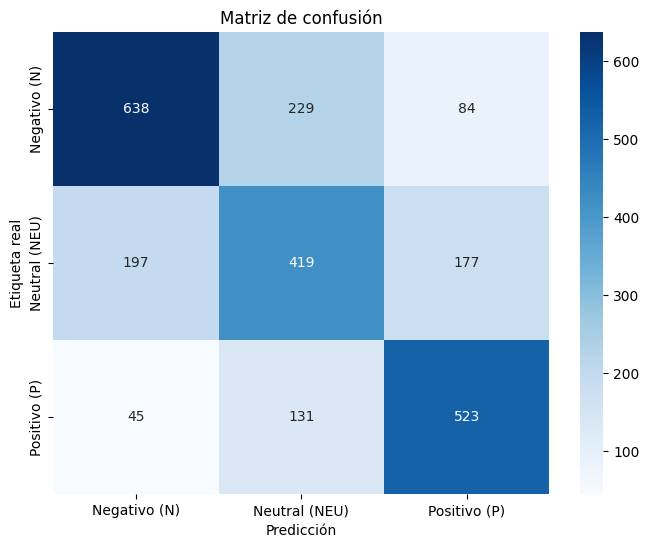

In [45]:
cm = confusion_matrix(labels, predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names.values(),
            yticklabels=label_names.values())
plt.xlabel('Predicción')
plt.ylabel('Etiqueta real')
plt.title('Matriz de confusión')
plt.show()

**CONCLUSIÓN**: La confusión sistemática más notable ocurre entre clases adyacentes en el espectro del sentimiento (negativo-neutral y neutral-positivo)

## Posibles sesgos del modelo: Comenta sobre patrones en los errores que puedan reflejar sesgos (por ejemplo, en tweets con ciertas palabras, emojis, o dialectos).

In [46]:
# Análisis de palabras específicas que pueden causar sesgos en el modelo
import pandas as pd
import re
import matplotlib.pyplot as plt
from collections import Counter
import seaborn as sns
import numpy as np

def analyze_biased_words(results_df):
    """
    Identifica palabras que aparecen desproporcionadamente en predicciones incorrectas

    Parámetros:
    results_df: DataFrame con columnas 'texto', 'etiqueta_real', 'etiqueta_predicha', 'correcta'
    """
    # Separar los casos correctos e incorrectos
    incorrect_preds = results_df[results_df['correcta'] == False]
    correct_preds = results_df[results_df['correcta'] == True]

    # Función para extraer palabras de textos
    def extract_words(texts):
        all_words = []
        for text in texts:
            # Limpieza y tokenización simple
            words = re.sub(r'[^\w\s]', '', text.lower()).split()
            all_words.extend(words)
        return all_words

    # Extraer palabras de predicciones correctas e incorrectas
    incorrect_words = extract_words(incorrect_preds['texto'])
    correct_words = extract_words(correct_preds['texto'])

    # Contar frecuencias
    incorrect_word_counts = Counter(incorrect_words)
    correct_word_counts = Counter(correct_words)

    # Normalizar por el número total de palabras en cada grupo
    total_incorrect = sum(incorrect_word_counts.values())
    total_correct = sum(correct_word_counts.values())

    # Encontrar palabras que aparecen desproporcionadamente en errores
    biased_words = {}
    for word, count in incorrect_word_counts.items():
        if word in correct_word_counts and len(word) > 3:  # Filtrar palabras cortas
            incorrect_ratio = count / total_incorrect
            correct_ratio = correct_word_counts[word] / total_correct
            # Una palabra se considera "sesgada" si aparece al menos dos veces más en errores que en aciertos
            # y si aparece al menos 5 veces en total en errores
            if incorrect_ratio > 2 * correct_ratio and count >= 5:
                biased_words[word] = incorrect_ratio / correct_ratio

    # Ordenar palabras por grado de sesgo (ratio incorrectas/correctas)
    sorted_biased_words = {k: v for k, v in sorted(biased_words.items(), key=lambda x: x[1], reverse=True)}

    # Mostrar resultados
    print(f"Se encontraron {len(sorted_biased_words)} palabras potencialmente sesgadas")

    if sorted_biased_words:
        # Tabla de las principales palabras sesgadas
        print("\nPalabras con mayor sesgo (Top 20):")
        print("Palabra | Ratio Incorrectas/Correctas | Frecuencia en Incorrectas | Frecuencia en Correctas")
        print("-" * 85)

        for i, (word, ratio) in enumerate(list(sorted_biased_words.items())[:20]):
            incorrect_freq = incorrect_word_counts[word]
            correct_freq = correct_word_counts[word]
            print(f"{word:15} | {ratio:.2f} | {incorrect_freq:25} | {correct_freq:22}")

        # Visualización de palabras sesgadas
        plt.figure(figsize=(14, 7))
        plt.bar(list(sorted_biased_words.keys())[:15], list(sorted_biased_words.values())[:15], color='crimson')
        plt.xticks(rotation=45, ha='right')
        plt.xlabel('Palabras')
        plt.ylabel('Ratio de frecuencia (incorrectas/correctas)')
        plt.title('Palabras con mayor presencia desproporcionada en predicciones incorrectas')
        plt.tight_layout()
        plt.show()

    return sorted_biased_words

Se encontraron 40 palabras potencialmente sesgadas

Palabras con mayor sesgo (Top 20):
Palabra | Ratio Incorrectas/Correctas | Frecuencia en Incorrectas | Frecuencia en Correctas
-------------------------------------------------------------------------------------
irme            | 9.11 |                         5 |                      1
puesto          | 9.11 |                         5 |                      1
videos          | 9.11 |                         5 |                      1
horario         | 9.11 |                         5 |                      1
misma           | 6.38 |                         7 |                      2
haber           | 5.47 |                         6 |                      2
poquito         | 5.47 |                         6 |                      2
prximo          | 4.56 |                         5 |                      2
cama            | 4.56 |                         5 |                      2
dias            | 4.25 |                         7 

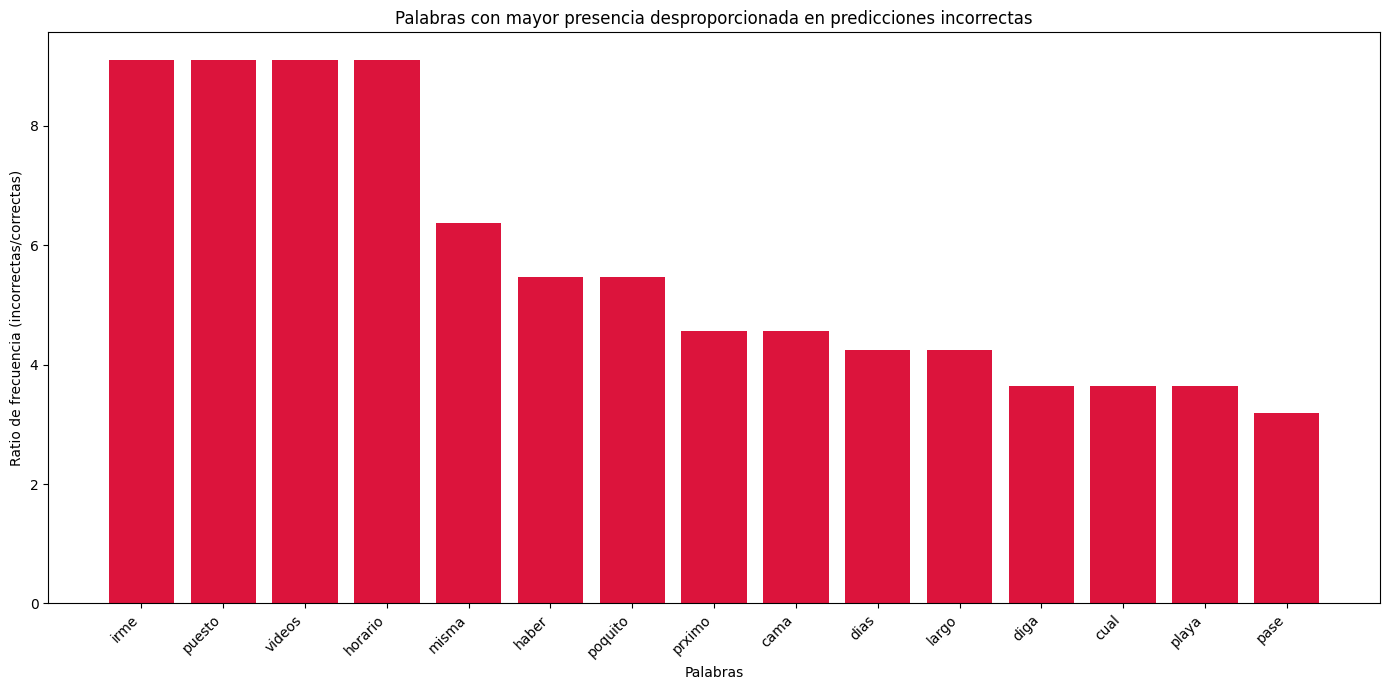

In [47]:
biased_words = analyze_biased_words(results_df)